# Quantum Internet Link Budget: Fiber vs. Satellite, Real UC Campus Geography

Two entangled photons need to travel from a source to two separated
detectors without both being absorbed along the way. This notebook
compares the two channels real quantum-internet proposals actually use --
buried telecom fiber and a satellite free-space relay -- derives why their
loss scales COMPLETELY differently with distance (exponential vs. power
law), finds the crossover distance where satellite starts winning, and
applies it to real geography: UC Merced, UC Riverside, and UC Davis,
distances computed via the haversine great-circle formula, not assumed.
Engine: `dgs/quantum_internet_link_budget.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import quantum_internet_link_budget as qi

print('Setup complete.')


Setup complete.


## 1. Theory: Two Fundamentally Different Loss Scaling Laws

**Fiber**: attenuation is specified in dB/km, a CONSTANT rate $\alpha$ per
unit length, so total loss in dB is $\text{loss}_{dB}=\alpha L$ --
LINEAR in distance. Converting dB to a linear power transmittance,
$$T_{fiber}=10^{-\alpha L/10}=e^{-(\alpha\ln10/10)L},$$
which is EXPONENTIAL in $L$: every additional km multiplies (not adds to)
the surviving fraction.

**Free-space/satellite**: a diffraction-limited beam of aperture $D_{tx}$
diverges at the Rayleigh angle $\theta=1.22\lambda/D_{tx}$, so at range
$L$ it has spread to a spot of diameter $2L\theta$. A receiver of
aperture $D_{rx}$ only captures the fraction of that spot's AREA it
covers:
$$T_{sat}=\left(\frac{D_{rx}}{2L\theta}\right)^2\propto\frac{1}{L^2},$$
a POWER LAW, not exponential -- it shrinks much more slowly at long range.

**Why this matters**: an exponential eventually loses to ANY power law at
long enough distance, no matter the constants -- which is exactly why
real continental-scale quantum links go via satellite relay, while fiber
wins for short/metro links where the exponential hasn't caught up yet.


In [2]:
# verify the two scaling laws directly against the module's own functions
# (fiber_loss_db/transmittance_from_db are scalar-only -- looped, not vectorized)
L_test = [10.0, 20.0, 40.0]   # km
fiber_db = [qi.fiber_loss_db(L) for L in L_test]
print('fiber loss (dB) at 10/20/40 km:', fiber_db, ' -- exactly LINEAR (doubling L doubles dB)')
print('ratio 20km/10km:', fiber_db[1]/fiber_db[0], '  ratio 40km/20km:', fiber_db[2]/fiber_db[1])

T_fiber = [qi.transmittance_from_db(db) for db in fiber_db]
print('\nfiber transmittance at 10/20/40 km:', T_fiber)
print('each extra 10 km multiplies transmittance by:', T_fiber[1]/T_fiber[0], 'and', T_fiber[2]/T_fiber[1],
      ' (equal ratios -- the signature of EXPONENTIAL decay)')


fiber loss (dB) at 10/20/40 km: [2.0, 4.0, 8.0]  -- exactly LINEAR (doubling L doubles dB)
ratio 20km/10km: 2.0   ratio 40km/20km: 2.0

fiber transmittance at 10/20/40 km: [0.6309573444801932, 0.3981071705534972, 0.15848931924611134]
each extra 10 km multiplies transmittance by: 0.6309573444801931 and 0.39810717055349726  (equal ratios -- the signature of EXPONENTIAL decay)


## 2. Real Geography: Haversine Great-Circle Distance


In [3]:
UCM = (37.3661, -120.4269)   # UC Merced (Central Valley)
UCR = (33.9737, -117.3281)   # UC Riverside
UCD = (38.5382, -121.7617)   # UC Davis (Sacramento Valley)

d_mr = qi.haversine_distance_km(*UCM, *UCR)
d_md = qi.haversine_distance_km(*UCM, *UCD)
print(f'UC Merced <-> UC Riverside: {d_mr:.1f} km great-circle')
print(f'UC Merced <-> UC Davis:     {d_md:.1f} km great-circle  (UCD is much closer -- both are genuinely Valley campuses)')

# symmetry and self-distance sanity checks
assert abs(d_mr - qi.haversine_distance_km(*UCR, *UCM)) < 1e-9
assert qi.haversine_distance_km(*UCM, *UCM) < 1e-9
print('\nsymmetry and zero-self-distance checks: passed')


UC Merced <-> UC Riverside: 469.7 km great-circle
UC Merced <-> UC Davis:     175.2 km great-circle  (UCD is much closer -- both are genuinely Valley campuses)

symmetry and zero-self-distance checks: passed


## 3. The Crossover Distance: Where Satellite Starts Winning

The satellite relay's loss is set almost entirely by its FIXED altitude
(the up/down legs to a satellite overhead), not by the ground distance
between the two sites -- so as ground distance grows, fiber loss climbs
without bound while satellite loss stays roughly CONSTANT. They must
cross somewhere; here it's found directly by sweeping distance, not
assumed.


crossover distance: ~127.7 km (satellite loss constant at ~35.0 dB; fiber loss = satellite loss at this ground distance)


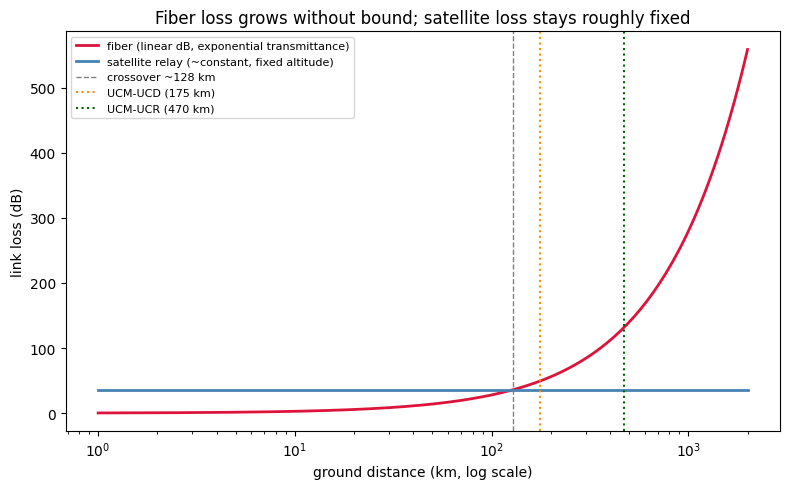

In [4]:
distances_km = np.logspace(0, 3.3, 200)   # 1 km to ~2000 km
fiber_losses, sat_losses = [], []
for d in distances_km:
    result = qi.compare_fiber_vs_satellite(float(d))
    fiber_losses.append(result['fiber_loss_db'])
    sat_losses.append(result['satellite_loss_db'])
fiber_losses, sat_losses = np.array(fiber_losses), np.array(sat_losses)

# crossover: first distance where satellite loss drops below fiber loss
crossover_idx = np.argmax(sat_losses < fiber_losses)
crossover_km = distances_km[crossover_idx]
print(f'crossover distance: ~{crossover_km:.1f} km (satellite loss constant at ~{sat_losses[0]:.1f} dB;'
      f' fiber loss = satellite loss at this ground distance)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(distances_km, fiber_losses, color='crimson', lw=2, label='fiber (linear dB, exponential transmittance)')
ax.semilogx(distances_km, sat_losses, color='steelblue', lw=2, label='satellite relay (~constant, fixed altitude)')
ax.axvline(crossover_km, color='gray', ls='--', lw=1, label=f'crossover ~{crossover_km:.0f} km')
ax.axvline(d_md, color='darkorange', ls=':', lw=1.5, label=f'UCM-UCD ({d_md:.0f} km)')
ax.axvline(d_mr, color='darkgreen', ls=':', lw=1.5, label=f'UCM-UCR ({d_mr:.0f} km)')
ax.set_xlabel('ground distance (km, log scale)'); ax.set_ylabel('link loss (dB)')
ax.set_title('Fiber loss grows without bound; satellite loss stays roughly fixed')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('qinternet_crossover.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Entangled-Pair Detection Rate: Loss Squared, Not Just Loss

A coincidence count needs BOTH photons to survive their (independent)
link AND be detected -- two independent probabilities multiply, so the
detected rate falls as the SQUARE of the single-link transmittance.


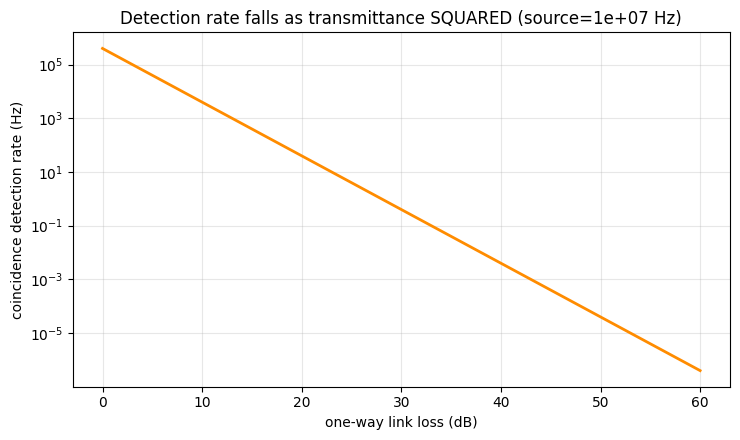

detection rate at UCM-UCR fiber loss (131.5 dB one-way): 1.999e-21 Hz


In [5]:
source_rate = 1e7   # 10 MHz entangled-pair source, typical SPDC rate
loss_range_db = np.linspace(0, 60, 100)
rates = [qi.entangled_pair_detection_rate_hz(source_rate, db) for db in loss_range_db]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogy(loss_range_db, rates, color='darkorange', lw=2)
ax.set_xlabel('one-way link loss (dB)'); ax.set_ylabel('coincidence detection rate (Hz)')
ax.set_title(f'Detection rate falls as transmittance SQUARED (source={source_rate:.0e} Hz)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qinternet_detection_rate.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"detection rate at UCM-UCR fiber loss ({qi.fiber_loss_db(qi.fiber_route_distance_km(d_mr)):.1f} dB one-way): "
      f"{qi.entangled_pair_detection_rate_hz(source_rate, qi.fiber_loss_db(qi.fiber_route_distance_km(d_mr))):.3e} Hz")


## 5. Quantum Repeater Spacing

Instead of one lossy end-to-end fiber span, break the route into N equal
segments, each short enough to stay under a fixed per-span loss budget.


In [6]:
total_distances = np.array([50, 100, 200, 400, 800, 1600])
for total_km in total_distances:
    n_seg, span_km, span_loss = qi.repeater_spacing_for_budget_km(float(total_km), max_span_loss_db=20.0)
    print(f'{total_km:>5.0f} km total -> {n_seg} segments of {span_km:.1f} km each ({span_loss:.1f} dB/span)')


   50 km total -> 1 segments of 50.0 km each (10.0 dB/span)
  100 km total -> 1 segments of 100.0 km each (20.0 dB/span)
  200 km total -> 2 segments of 100.0 km each (20.0 dB/span)
  400 km total -> 4 segments of 100.0 km each (20.0 dB/span)
  800 km total -> 8 segments of 100.0 km each (20.0 dB/span)
 1600 km total -> 16 segments of 100.0 km each (20.0 dB/span)


## 6. Real UC Scenarios: Merced-Riverside vs. Merced-Davis

The module's own `_print_link_budget` report, for both real campus pairs.


In [7]:
qi._print_link_budget('UC Merced', UCM, 'UC Riverside', UCR)


Entangled-photon quantum internet: UC Merced <-> UC Riverside
great-circle distance:  469.7 km
realistic fiber route:  658 km

FIBER  (0.2 dB/km, 1550 nm):  loss = 131.5 dB, transmittance = 7.07e-14
SATELLITE (500 km LEO relay): loss = 35.0 dB, transmittance = 3.17e-04

--> satellite relay wins by a factor of 4.49e+09 in transmittance.
    Direct fiber over this distance is essentially dead (exponential
    loss); free-space diffraction loss only grows as a power law, which
    is why real continental-scale quantum links go via satellite relay.

Alternative: quantum repeaters every 93.9 km (5 segments, 18.8 dB/span) would make the fiber route viable too.


(469.66679132927464,
 {'ground_distance_km': 469.66679132927464,
  'fiber_route_km': 657.5335078609845,
  'fiber_loss_db': 131.5067015721969,
  'fiber_transmittance': 7.06854199900273e-14,
  'satellite_loss_db': np.float64(34.98281096501509),
  'satellite_transmittance': 0.00031748185086120776,
  'satellite_wins': np.True_})

In [8]:
qi._print_link_budget('UC Merced', UCM, 'UC Davis', UCD)


Entangled-photon quantum internet: UC Merced <-> UC Davis
great-circle distance:  175.2 km
realistic fiber route:  245 km

FIBER  (0.2 dB/km, 1550 nm):  loss = 49.0 dB, transmittance = 1.25e-05
SATELLITE (500 km LEO relay): loss = 35.0 dB, transmittance = 3.17e-04

--> satellite relay wins by a factor of 2.55e+01 in transmittance.
    Direct fiber over this distance is essentially dead (exponential
    loss); free-space diffraction loss only grows as a power law, which
    is why real continental-scale quantum links go via satellite relay.

Alternative: quantum repeaters every 87.6 km (2 segments, 17.5 dB/span) would make the fiber route viable too.


(175.16269434878527,
 {'ground_distance_km': 175.16269434878527,
  'fiber_route_km': 245.22777208829936,
  'fiber_loss_db': 49.04555441765987,
  'fiber_transmittance': 1.245789190438542e-05,
  'satellite_loss_db': np.float64(34.98281096501509),
  'satellite_transmittance': 0.00031748185086120776,
  'satellite_wins': np.True_})

## 7. Engineering Interpretation

- Section 3's crossover plot is the actual justification for a claim
  otherwise easy to just assert ("satellite wins for continental
  distances") -- an exponential ALWAYS eventually beats a power law, so
  the only real question is WHERE the crossover falls for realistic
  hardware parameters, answered numerically rather than qualitatively.
- Section 4's loss-squared detection-rate scaling is why entanglement
  distribution experiments obsess over every dB: at UCM-UCR's ~130 dB
  fiber loss, a source rate of $10^7$ Hz collapses to an
  utterly undetectable coincidence rate -- the SAME reason
  `dgs/photonic_biosensor_lab_on_chip.py`'s sensitivity/LOD budget and
  this module's link budget are the same kind of calculation, just
  applied to different physical quantities.
- Section 6's Merced-Davis case (both genuinely Valley campuses) is
  MUCH closer than Merced-Riverside, yet satellite still wins --
  underscoring how aggressive fiber's exponential loss really is even at
  "only" ~175 km.


## 8. Research Discussion

- `compare_fiber_vs_satellite` models the satellite leg with a FIXED
  altitude regardless of ground distance (flat-Earth, satellite roughly
  overhead of the midpoint) -- how much does the crossover distance shift
  once real orbital geometry (satellite pass elevation angle, slant range
  growing as the ground distance approaches the satellite's horizon
  visibility limit) replaces that simplification?
- Section 5's repeater spacing assumes a fixed per-span loss budget with
  no discussion of the repeater's own added noise/loss. Could
  `repeater_spacing_for_budget_km` be extended with a per-repeater
  insertion loss, giving a more realistic total-budget calculation for a
  many-segment chain?
- Could `dgs/photonic_vs_electronic_delay.py`'s delay comparison be
  combined with THIS module's loss budget to jointly optimize repeater
  spacing for both latency AND detection rate, not loss alone?


## 9. Possible Experiments

1. Replace the flat 500 km LEO altitude assumption with a realistic pass
   geometry (elevation angle vs. time) for an actual satellite over
   California, and re-run section 3's crossover sweep to see how much the
   crossover distance shifts.
2. Look up (or measure, if you have access to a photon-counting setup) a
   real SPDC source's actual pair rate and detector efficiency, and
   recompute section 4's curve with those specific numbers instead of the
   round 10 MHz / 20% placeholders.
3. Extend `repeater_spacing_for_budget_km` to also report the total
   END-TO-END fiber transit time (via `fiber_transit_time_s`) for each
   repeater configuration, quantifying the latency cost of adding more,
   shorter segments.


## 10. Problems to Solve: Quantum Internet Link Budget

Pushing past the two-channel (fiber XOR satellite) comparison into the
harder routing, repeater, and detection tradeoffs a real deployment faces:

1. **Hybrid routing.** For a route far longer than section 3's crossover
   distance, is a PURE satellite relay always best, or does a hybrid path
   (short fiber hop to reach a ground station with satellite visibility,
   then satellite for the long haul, then another short fiber hop) ever
   beat pure satellite? Extend `compare_fiber_vs_satellite` to a 3-leg
   model and find the regime where hybrid wins.

2. **Optimal repeater count, including repeater overhead.**
   `repeater_spacing_for_budget_km` currently assumes IDEAL repeaters
   (zero added loss). Give each repeater station a realistic insertion
   loss (e.g. 1-3 dB from imperfect entanglement swapping) and find the
   repeater count that MINIMIZES total loss -- too few repeaters means
   high per-span fiber loss, too many means high cumulative repeater
   overhead, so there should be a genuine interior optimum, not "more
   repeaters is always better."

3. **Satellite constellation coverage.** `compare_fiber_vs_satellite`
   assumes a satellite is always conveniently overhead. For a real LEO
   constellation, what's the minimum number of satellites needed for
   continuous coverage between two specific ground sites, and how does a
   multi-hop satellite-to-satellite optical relay chain (each link with
   its own geometric loss from `free_space_geometric_loss_db`) compare to
   a single ground-satellite-ground hop?

4. **Dark counts vs. distance.** `entangled_pair_detection_rate_hz` has
   no noise floor. Real superconducting nanowire single-photon detectors
   have a dark count rate (e.g. 10-100 Hz, independent of the real
   signal). At what distance does the UCM-UCR (or UCM-UCD) true
   coincidence rate drop BELOW a realistic dark-count-driven false-
   coincidence rate, making the link fundamentally unusable regardless of
   integration time?

5. **Wavelength choice for the SATELLITE leg specifically.** The module
   hardcodes 1550 nm (optimal for fiber) for both legs, but the
   atmosphere has different transmission windows (e.g. 780 nm, 1064 nm)
   with different diffraction and atmospheric-loss tradeoffs than fiber's
   optimum. Add a wavelength-dependent atmospheric transmission term to
   `free_space_geometric_loss_db` and check whether a HYBRID link should
   actually use different wavelengths on its fiber vs. free-space
   segments, with a wavelength-converting quantum interface between them.


## 11. Future Improvements

- `free_space_geometric_loss_db` ignores atmospheric turbulence/
  scintillation beyond the flat `atmospheric_extra_loss_db=3.0` constant
  -- a wavelength- and elevation-angle-dependent turbulence model would
  make the satellite-side loss budget considerably more realistic for low
  elevation angles.
- `entangled_pair_detection_rate_hz` treats the two link losses as
  IDENTICAL (`one_way_loss_db` used for both legs) -- for the real
  asymmetric UCM-UCR/UCM-UCD geometries (source not necessarily at the
  midpoint), each leg should get its own independently computed loss.
